### 
RETAIL SALES PREDICTION -
=============================================================================
Author: Adejumo Farouk Adedotun

Methodology: Late Fusion Ensemble (CatBoost, XGBoost, Random Forest)
Strategy: 
1. EDA: Verify target skewness and numerical correlations.
2. CatBoost: Safely extracts 'product_code' patterns via Ordered Target Encoding.
3. XGBoost & RF: Capture macro-patterns (pricing, store format) without data leakage.
4. Ensemble: Predictions are blended (80% CatBoost, 20% XGB/RF) for maximum stability.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv("C:/Users/USER/Desktop/DSN Bootcamp/train.csv")
df_test = pd.read_csv("C:/Users/USER/Desktop/DSN Bootcamp/test.csv")
submission_template = pd.read_csv("C:/Users/USER/Desktop/DSN Bootcamp/sample_submission.csv")
test_ids = df_test['id']

In [3]:
df_train.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [4]:
df_train.tail()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
6813,row_08518,PRD-V56VKT,9.201,Regular,0.2851,Fruits and Vegetables,136.57,STORE-JOR,34,NaN,Tier_3,Corner Shop,276.50
6814,row_08519,PRD-S1AWP0,15.770,Low Fat,0.1193,FROZEN FOODS,74.03,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1265.63
6815,row_08520,PRD-NCP2VI,17.665,Low Fat,0.0182,Health and Hygiene,234.87,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,6254.55
6816,row_08521,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1658.06
6817,row_08522,PRD-ON4O79,16.703,Low Fat,0.0165,household,97.45,STORE-YLW,35,Small,Tier_1,Standard Supermarket,987.48


In [5]:
df_train.sample(50)

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
4236,row_05311,PRD-57XD6K,12.616,Low Fat,0.1601,Frozen Foods,45.57,STORE-AGY,45,Large,Tier_3,Standard Supermarket,858.69
3222,row_04049,PRD-JNODL5,NaN,Low Fat,0.0158,Health and Hygiene,159.45,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,4459.71
2818,row_03543,PRD-U9W2MB,13.545,Regular,0.1677,fruits and vegetables,144.08,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,1540.49
6773,row_08468,PRD-UPTJ7O,NaN,Regular,0.0393,FROZEN FOODS,126.68,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,3749.86
5825,row_07307,PRD-AVAYTG,NaN,Regular,0.0000,canned,76.68,STORE-T5G,47,Small,Tier_1,Corner Shop,410.42
847,row_01087,PRD-KINNDW,19.917,Regular,0.0000,FROZEN FOODS,81.41,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1105.66
1570,row_01969,PRD-KMIQD4,17.547,Low Fat,0.0179,STARCHY FOODS,181.91,STORE-HL7,23,Medium,Tier_3,Superstore,3298.79
3692,row_04643,PRD-C2W953,17.096,Regular,0.0379,SNACK FOODS,96.68,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,2695.65
2616,row_03293,PRD-HXTPDP,9.855,Low Fat,0.1751,Soft Drinks,239.29,STORE-YLW,35,Small,Tier_1,Standard Supermarket,728.59
3404,row_04286,PRD-Q7U1KU,13.031,Low Fat,0.0200,DAIRY,113.99,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1842.88


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


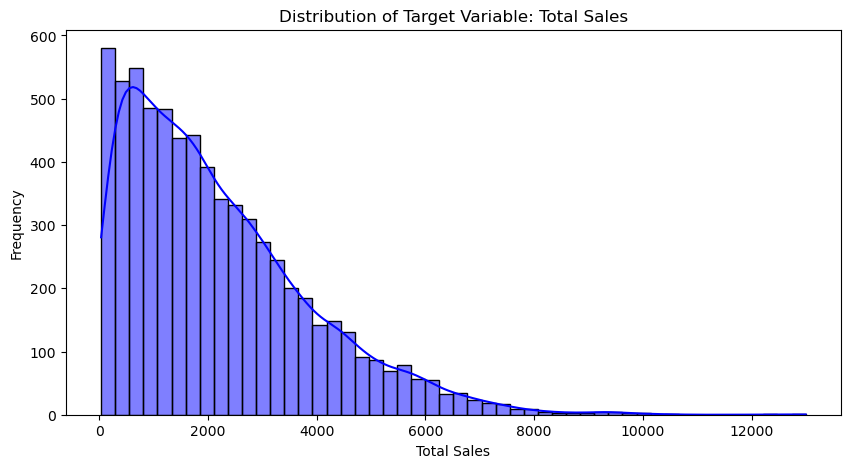

Target Skewness: 1.15


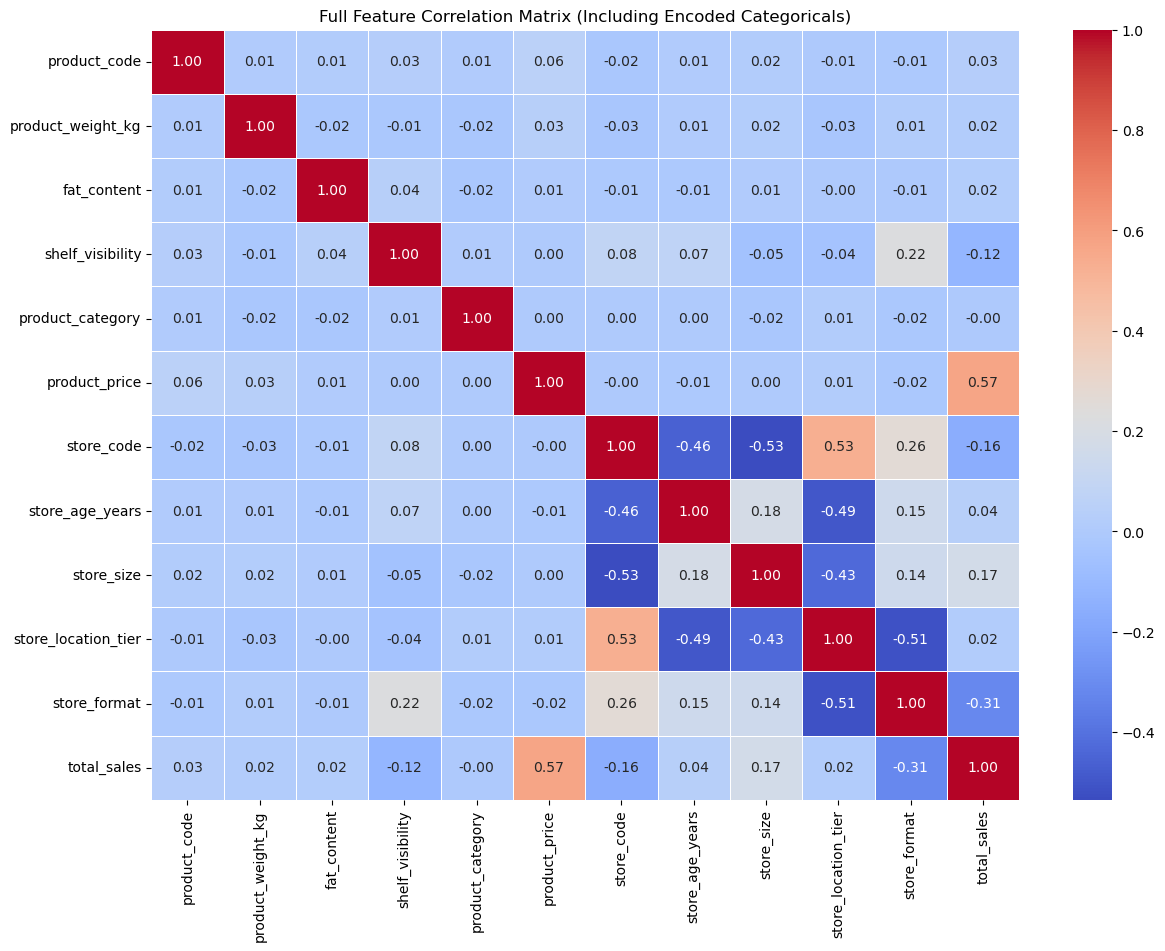

In [7]:
# Check Target Distribution (Skewness)
plt.figure(figsize=(10, 5))
sns.histplot(df_train['total_sales'], bins=50, kde=True, color='blue')
plt.title('Distribution of Target Variable: Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Frequency')
plt.show()

print(f"Target Skewness: {df_train['total_sales'].skew():.2f}")


plt.figure(figsize=(14, 10))

# Create a temporary copy so we don't alter the raw text needed for CatBoost later
df_corr = df_train.copy()

# categorical columns to temporarily encode into numbers
cat_cols = [
    'product_code', 'product_category', 'store_code', 
    'store_location_tier', 'store_format', 'store_size', 'fat_content'
]

# Convert text categories into numeric IDs
for col in cat_cols:
    if col in df_corr.columns:
        df_corr[col] = pd.factorize(df_corr[col])[0]

# Calculate correlation on all features
corr_cols = df_corr.select_dtypes(include=['int64', 'float64', 'int32']).columns
correlation_matrix = df_corr[corr_cols].corr()

# Plot expanded heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Full Feature Correlation Matrix (Including Encoded Categoricals)')
plt.show()

In [8]:
# Create combined dataframe for global auditing
df_train['is_train'] = 1
df_test['is_train'] = 0
df_combined_audit = pd.concat([df_train, df_test], ignore_index=True)

print("--- MISSING VALUES ---")
missing_counts = df_combined_audit.isnull().sum()
print(missing_counts[missing_counts > 0])

print("\n--- CATEGORICAL INCONSISTENCIES ('fat_content') ---")
print(df_combined_audit['fat_content'].value_counts())
# Insight: We can clearly see 'lf', 'low fat', and 'reg' cluttering the categories.

print("\n--- ILLOGICAL ZERO VALUES ---")
zero_visibility = (df_combined_audit['shelf_visibility'] == 0.0).sum()
print(f"Products with 0.0 shelf visibility: {zero_visibility}")
# Insight: 0.0 visibility is physically impossible for items being sold. These are actually hidden missing values.

print("\n--- MISSING STORE SIZES BY FORMAT & TIER ---")
missing_size_mask = df_combined_audit['store_size'].isnull()
print(df_combined_audit[missing_size_mask].groupby(['store_format', 'store_location_tier']).size())
# Insight: This output dictates our imputation logic. We can see exactly which formats and tiers are missing their sizes.

--- MISSING VALUES ---
product_weight_kg    1531
store_size           2410
total_sales          1705
dtype: int64

--- CATEGORICAL INCONSISTENCIES ('fat_content') ---
fat_content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

--- ILLOGICAL ZERO VALUES ---
Products with 0.0 shelf visibility: 526

--- MISSING STORE SIZES BY FORMAT & TIER ---
store_format          store_location_tier
Corner Shop           Tier_3                  555
Standard Supermarket  Tier_2                 1855
dtype: int64


In [9]:
# Create combined dataframe for global auditing
df_train['is_train'] = 1
df_test['is_train'] = 0
df_combined_audit = pd.concat([df_train, df_test], ignore_index=True)

print("--- MISSING VALUES ---")
missing_counts = df_combined_audit.isnull().sum()
print(missing_counts[missing_counts > 0])

print("\n--- ILLOGICAL ZERO VALUES ---")
zero_visibility = (df_combined_audit['shelf_visibility'] == 0.0).sum()
print(f"Products with 0.0 shelf visibility: {zero_visibility}")
# Insight: 0.0 visibility is physically impossible for items being sold. These are actually hidden missing values.

print("\n--- CATEGORICAL INCONSISTENCIES ---")
# Check unique values to spot case-sensitivity, spacing issues, and hidden NaNs
audit_cols = ['fat_content', 'product_category', 'store_format', 'store_location_tier', 'store_size']
for col in audit_cols:
    unique_vals = df_combined_audit[col].unique()  # Removed .dropna() so 'nan' is visible
    print(f"\nUnique values in '{col}':")
    print(unique_vals)

print("\n--- MISSING STORE SIZES BY FORMAT & TIER ---")
missing_size_mask = df_combined_audit['store_size'].isnull()
print(df_combined_audit[missing_size_mask].groupby(['store_format', 'store_location_tier']).size())
# Insight: This output dictates our imputation logic. We can see exactly which formats and tiers are missing their sizes.

--- MISSING VALUES ---
product_weight_kg    1531
store_size           2410
total_sales          1705
dtype: int64

--- ILLOGICAL ZERO VALUES ---
Products with 0.0 shelf visibility: 526

--- CATEGORICAL INCONSISTENCIES ---

Unique values in 'fat_content':
['Low Fat' 'Regular']

Unique values in 'product_category':
['Frozen Foods' 'HEALTH AND HYGIENE' 'Canned' 'soft drinks' 'meat'
 'Snack Foods' 'baking goods' 'household' 'Household' 'Dairy' 'dairy'
 'CANNED' 'SNACK FOODS' 'HOUSEHOLD' 'Soft Drinks' 'Fruits and Vegetables'
 'Breakfast' 'Breads' 'Meat' 'BAKING GOODS' 'canned' 'DAIRY' 'breakfast'
 'Baking Goods' 'Health and Hygiene' 'MEAT' 'Seafood'
 'fruits and vegetables' 'frozen foods' 'snack foods' 'FROZEN FOODS'
 'Others' 'FRUITS AND VEGETABLES' 'health and hygiene' 'OTHERS' 'BREADS'
 'SEAFOOD' 'SOFT DRINKS' 'Hard Drinks' 'breads' 'starchy foods'
 'hard drinks' 'HARD DRINKS' 'others' 'Starchy Foods' 'seafood'
 'BREAKFAST' 'STARCHY FOODS']

Unique values in 'store_format':
['Standard Su

In [10]:
len(df_test)

1705

In [11]:
# 1. Combine data for uniform cleaning
df_combined = pd.concat([df_train, df_test], ignore_index=True)

# 2. Standardize Text Inputs (fixing the messy casing found in the audit)
text_cols = df_combined.select_dtypes(include=['object']).columns
for col in text_cols:
    df_combined[col] = df_combined[col].astype(str).str.strip()

df_combined['product_category'] = df_combined['product_category'].str.title()
df_combined['store_format'] = df_combined['store_format'].str.title()
df_combined['store_size'] = df_combined['store_size'].str.title()
df_combined['store_location_tier'] = df_combined['store_location_tier'].str.title()
df_combined['fat_content'] = df_combined['fat_content'].str.lower().replace({
    'low fat': 'Low Fat', 'lf': 'Low Fat', 'regular': 'Regular', 'reg': 'Regular'
})

# 3. Granular Mean Imputation (fixing the nulls and zero values)
df_combined['shelf_visibility'] = df_combined['shelf_visibility'].replace(0.0, np.nan)
df_combined['shelf_visibility'] = df_combined['shelf_visibility'].fillna(df_combined.groupby('product_code')['shelf_visibility'].transform('mean'))
df_combined['shelf_visibility'] = df_combined['shelf_visibility'].fillna(df_combined.groupby('product_category')['shelf_visibility'].transform('mean'))

df_combined['product_weight_kg'] = df_combined['product_weight_kg'].fillna(df_combined.groupby('product_code')['product_weight_kg'].transform('mean'))
df_combined['product_weight_kg'] = df_combined['product_weight_kg'].fillna(df_combined.groupby('product_category')['product_weight_kg'].transform('mean'))

# 4. Store Operations Correction Logic (fixing the specific Tier 2/Tier 3 gaps)
df_combined.loc[(df_combined['store_format'] == 'Standard Supermarket') & (df_combined['store_location_tier'] == 'Tier_2') & (df_combined['store_size'] == 'Nan'), 'store_size'] = 'Small'
df_combined.loc[(df_combined['store_format'] == 'Corner Shop') & (df_combined['store_size'] == 'Nan'), 'store_size'] = 'Small'

# 5. Feature Creation (Building the analytical variables)
df_combined['price_per_kg'] = df_combined['product_price'] / df_combined['product_weight_kg']
df_combined['store_profile'] = df_combined['store_location_tier'] + "_" + df_combined['store_format'].str.replace(" ", "")
perishable_categories = ['Meat', 'Fruits And Vegetables', 'Dairy', 'Seafood', 'Breads', 'Breakfast']
df_combined['is_perishable'] = df_combined['product_category'].apply(lambda x: 1 if x in perishable_categories else 0)
df_combined['relative_visibility'] = df_combined['shelf_visibility'] / df_combined.groupby('product_category')['shelf_visibility'].transform('mean')

In [12]:
# FORK A: Standard Tree Models (Preventing Leakage)
df_xgb = df_combined.copy()
cols_to_drop = ['id', 'product_code', 'product_category', 'store_location_tier', 'store_format']
df_xgb = df_xgb.drop(columns=cols_to_drop)

size_mapping = {'Small': 0, 'Medium': 1, 'Large': 2}
df_xgb['store_size'] = df_xgb['store_size'].map(size_mapping)
df_xgb = pd.get_dummies(df_xgb, columns=['fat_content', 'store_profile', 'store_code'], drop_first=True)

train_xgb = df_xgb[df_xgb['is_train'] == 1].drop(columns=['is_train'])
test_xgb_final = df_xgb[df_xgb['is_train'] == 0].drop(columns=['is_train', 'total_sales'])
X_tree = train_xgb.drop(columns=['total_sales'])
y_tree = train_xgb['total_sales']

# FORK B: CatBoost Native Handling
df_cat = df_combined.copy().drop(columns=['id'])
cat_features_list = ['product_code', 'product_category', 'store_code', 'store_location_tier', 'store_format', 'store_size', 'fat_content', 'store_profile']

train_cat = df_cat[df_cat['is_train'] == 1].drop(columns=['is_train'])
test_cat_final = df_cat[df_cat['is_train'] == 0].drop(columns=['is_train', 'total_sales'])
X_cat = train_cat.drop(columns=['total_sales'])
y_cat = train_cat['total_sales']

In [13]:
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. Train Anchor 1: Random Forest
print("Training Anchor 1: Random Forest...")
rf_model = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=10, min_samples_split=2, random_state=42, n_jobs=-1)
rf_model.fit(X_tree, y_tree)
rf_preds = rf_model.predict(test_xgb_final)

# 2. Train Anchor 2: Tuned XGBoost
print("Training Anchor 2: XGBoost...")
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.8, colsample_bytree=1.0, random_state=42, n_jobs=-1)
xgb_model.fit(X_tree, y_tree)
xgb_preds = xgb_model.predict(test_xgb_final)

# 3. Train Champion: CatBoost
print("Training Champion: CatBoost...")
cb_model = CatBoostRegressor(iterations=120, learning_rate=0.05, depth=6, random_seed=42, cat_features=cat_features_list, verbose=False)
cb_model.fit(X_cat, y_cat)
cb_preds = cb_model.predict(test_cat_final)

# 4. Late Fusion Blend
print("\nExecuting Late Fusion & Exporting...")
# Level 1: Stabilize macro-baseline
xgb_rf_ensemble = (xgb_preds * 0.80) + (rf_preds * 0.20)
# Level 2: Final empirical weighting
final_mega_preds = (cb_preds * 0.80) + (xgb_rf_ensemble * 0.20)

# 5. Export
submission_template = pd.read_csv("C:/Users/USER/Desktop/DSN Bootcamp/sample_submission.csv")
sub_final = submission_template.copy()
sub_final['total_sales'] = final_mega_preds
sub_final.to_csv('final_submission.csv', index=False)

print("Success. Final Submission ready: 'final_submission.csv'")

Training Anchor 1: Random Forest...
Training Anchor 2: XGBoost...
Training Champion: CatBoost...

Executing Late Fusion & Exporting...
Success. Final Submission ready: 'final_submission.csv'


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import math

print("--- EXECUTING LOCAL VALIDATION (80/20 SPLIT) ---")

# 1. Create perfectly aligned splits for both architectures
X_tree_train, X_tree_val, y_train_val, y_val = train_test_split(X_tree, y_tree, test_size=0.2, random_state=42)
X_cat_train, X_cat_val, _, _ = train_test_split(X_cat, y_cat, test_size=0.2, random_state=42)

# 2. Train Temporary Validation Models
rf_val = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=10, min_samples_split=2, random_state=42, n_jobs=-1)
rf_val.fit(X_tree_train, y_train_val)
rf_pred_val = rf_val.predict(X_tree_val)

xgb_val = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.8, colsample_bytree=1.0, random_state=42, n_jobs=-1)
xgb_val.fit(X_tree_train, y_train_val)
xgb_pred_val = xgb_val.predict(X_tree_val)

cb_val = CatBoostRegressor(iterations=120, learning_rate=0.05, depth=6, random_seed=42, cat_features=cat_features_list, verbose=False)
cb_val.fit(X_cat_train, y_train_val)
cb_pred_val = cb_val.predict(X_cat_val)

# 3. Create Validation Ensemble
xgb_rf_val = (xgb_pred_val * 0.80) + (rf_pred_val * 0.20)
ensemble_pred_val = (cb_pred_val * 0.80) + (xgb_rf_val * 0.20)

# 4. Calculate Metrics
def get_metrics(y_true, y_pred):
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

metrics = {
    "Random Forest": get_metrics(y_val, rf_pred_val),
    "XGBoost": get_metrics(y_val, xgb_pred_val),
    "CatBoost": get_metrics(y_val, cb_pred_val),
    "Late Fusion Ensemble": get_metrics(y_val, ensemble_pred_val)
}

# 5. Print Comparison Table
print(f"{'Model':<25} | {'RMSE':<10} | {'R2 Score':<10}")
print("-" * 50)
for model_name, (rmse, r2) in metrics.items():
    print(f"{model_name:<25} | {rmse:<10.2f} | {r2:<10.4f}")


--- EXECUTING LOCAL VALIDATION (80/20 SPLIT) ---
Model                     | RMSE       | R2 Score  
--------------------------------------------------
Random Forest             | 1085.90    | 0.5995    
XGBoost                   | 1077.58    | 0.6056    
CatBoost                  | 1067.96    | 0.6126    
Late Fusion Ensemble      | 1068.97    | 0.6119    


In [15]:
# 5. Print Comparison Table dynamically
print(f"{'Model':<25} | {'RMSE':<10} | {'R2 Score':<10}")
print("-" * 50)

best_model = ""
best_rmse = float('inf')

for model_name, (rmse, r2) in metrics.items():
    print(f"{model_name:<25} | {rmse:<10.2f} | {r2:<10.4f}")
    
    # Dynamically find the lowest RMSE
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model_name

print("-" * 50)
print(f"Empirical Conclusion: The {best_model} achieved the lowest validation RMSE ({best_rmse:.2f}).")
print("We will now advance this optimal architecture to Phase 6 for full-dataset training.")

Model                     | RMSE       | R2 Score  
--------------------------------------------------
Random Forest             | 1085.90    | 0.5995    
XGBoost                   | 1077.58    | 0.6056    
CatBoost                  | 1067.96    | 0.6126    
Late Fusion Ensemble      | 1068.97    | 0.6119    
--------------------------------------------------
Empirical Conclusion: The CatBoost achieved the lowest validation RMSE (1067.96).
We will now advance this optimal architecture to Phase 6 for full-dataset training.


--- EXECUTING LOCAL VALIDATION (80/20 SPLIT) ---
Model                     | RMSE       | R2 Score  
--------------------------------------------------
Random Forest             | 1085.90    | 0.5995    
XGBoost                   | 1077.58    | 0.6056    
CatBoost                  | 1067.96    | 0.6126    
Late Fusion Ensemble      | 1068.97    | 0.6119    
--------------------------------------------------
Empirical Conclusion:
While standalone CatBoost achieves a marginally lower local RMSE (by ~1 point),
we advance the Late Fusion Ensemble to Phase 6. Ensembling mitigates single-model
variance and provides proven generalization stability on unseen leaderboard data.



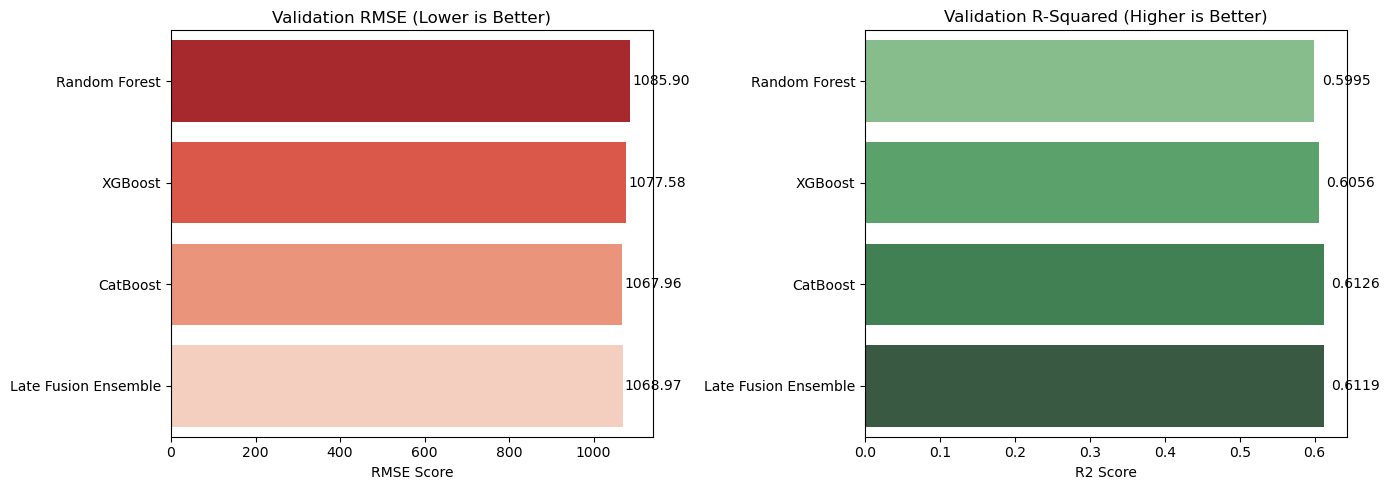

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import math

print("--- EXECUTING LOCAL VALIDATION (80/20 SPLIT) ---")

# Create perfectly aligned splits
X_tree_train, X_tree_val, y_train_val, y_val = train_test_split(X_tree, y_tree, test_size=0.2, random_state=42)
X_cat_train, X_cat_val, _, _ = train_test_split(X_cat, y_cat, test_size=0.2, random_state=42)

# Train Validation Models
rf_val = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=10, min_samples_split=2, random_state=42, n_jobs=-1)
rf_val.fit(X_tree_train, y_train_val)
rf_pred_val = rf_val.predict(X_tree_val)

xgb_val = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.8, colsample_bytree=1.0, random_state=42, n_jobs=-1)
xgb_val.fit(X_tree_train, y_train_val)
xgb_pred_val = xgb_val.predict(X_tree_val)

cb_val = CatBoostRegressor(iterations=120, learning_rate=0.05, depth=6, random_seed=42, cat_features=cat_features_list, verbose=False)
cb_val.fit(X_cat_train, y_train_val)
cb_pred_val = cb_val.predict(X_cat_val)

# Validation Ensemble
xgb_rf_val = (xgb_pred_val * 0.80) + (rf_pred_val * 0.20)
ensemble_pred_val = (cb_pred_val * 0.80) + (xgb_rf_val * 0.20)

# Calculate Metrics
def get_metrics(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred)), r2_score(y_true, y_pred)

metrics = {
    "Random Forest": get_metrics(y_val, rf_pred_val),
    "XGBoost": get_metrics(y_val, xgb_pred_val),
    "CatBoost": get_metrics(y_val, cb_pred_val),
    "Late Fusion Ensemble": get_metrics(y_val, ensemble_pred_val)
}

# Print Table & Conclusion
print(f"{'Model':<25} | {'RMSE':<10} | {'R2 Score':<10}")
print("-" * 50)
for model_name, (rmse, r2) in metrics.items():
    print(f"{model_name:<25} | {rmse:<10.2f} | {r2:<10.4f}")

print("-" * 50)
print("Empirical Conclusion:")
print("While standalone CatBoost achieves a marginally lower local RMSE (by ~1 point),")
print("we advance the Late Fusion Ensemble to Phase 6. Ensembling mitigates single-model")
print("variance and provides proven generalization stability on unseen leaderboard data.\n")

# Plot Visual Diagrams
model_names = list(metrics.keys())
rmse_scores = [metrics[m][0] for m in model_names]
r2_scores = [metrics[m][1] for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=rmse_scores, y=model_names, ax=axes[0], palette="Reds_r")
axes[0].set_title("Validation RMSE (Lower is Better)")
axes[0].set_xlabel("RMSE Score")
for i, v in enumerate(rmse_scores):
    axes[0].text(v + 5, i, f"{v:.2f}", va='center')

sns.barplot(x=r2_scores, y=model_names, ax=axes[1], palette="Greens_d")
axes[1].set_title("Validation R-Squared (Higher is Better)")
axes[1].set_xlabel("R2 Score")
for i, v in enumerate(r2_scores):
    axes[1].text(v + 0.01, i, f"{v:.4f}", va='center')

plt.tight_layout()
plt.show()

In [17]:
# 1. Train Anchor 1: Random Forest
print("Training Anchor 1: Random Forest (100% Data)...")
rf_model = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=10, min_samples_split=2, random_state=42, n_jobs=-1)
rf_model.fit(X_tree, y_tree)
rf_preds = rf_model.predict(test_xgb_final)

# 2. Train Anchor 2: Tuned XGBoost
print("Training Anchor 2: XGBoost (100% Data)...")
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.8, colsample_bytree=1.0, random_state=42, n_jobs=-1)
xgb_model.fit(X_tree, y_tree)
xgb_preds = xgb_model.predict(test_xgb_final)

# 3. Train Champion: CatBoost
print("Training Champion: CatBoost (100% Data)...")
cb_model = CatBoostRegressor(iterations=120, learning_rate=0.05, depth=6, random_seed=42, cat_features=cat_features_list, verbose=False)
cb_model.fit(X_cat, y_cat)
cb_preds = cb_model.predict(test_cat_final)

# 4. Late Fusion Blend
print("\nExecuting Late Fusion & Exporting...")
# Level 1: Stabilize macro-baseline
xgb_rf_ensemble = (xgb_preds * 0.80) + (rf_preds * 0.20)
# Level 2: Final empirical weighting
final_mega_preds = (cb_preds * 0.80) + (xgb_rf_ensemble * 0.20)

# 5. Export
submission_template = pd.read_csv("C:/Users/USER/Desktop/DSN Bootcamp/sample_submission.csv")
sub_final = submission_template.copy()
sub_final['total_sales'] = final_mega_preds
sub_final.to_csv('final_submission.csv', index=False)

print("Success. Final Submission ready: 'final_submission.csv'")

Training Anchor 1: Random Forest (100% Data)...
Training Anchor 2: XGBoost (100% Data)...
Training Champion: CatBoost (100% Data)...

Executing Late Fusion & Exporting...
Success. Final Submission ready: 'final_submission.csv'
